In [1]:
# Import core data manipulation and matrix environment libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Import preprocessing and model evaluation metrics from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report
# Automatically create the required results output folder if it does not exist
os.makedirs('results', exist_ok=True)
print("Cell 1 Execution Success: Libraries loaded and results directory verified.")

Cell 1 Execution Success: Libraries loaded and results directory verified.


In [2]:
## Task 1 – Dataset Understanding

# Load the targeted customer churn dataset into a structured pandas DataFrame
df = pd.read_csv('customer_churn_nn.csv')

# Task 1.1: Extract and print the exact dimensions of the dataset matrix
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Task 1.2 & 1.4: Inspect underlying feature data types and identify missing values
print("--- Dataset Column Properties and Structural Information ---")
print(df.info())

# Task 1.4: Print precise sum of missing values for verification
print("\n--- Missing Value Count Per Feature Column ---")
print(df.isnull().sum())

# Task 1.5: Generate complete basic statistical summary matrix for all attributes
print("\n--- Descriptive Statistical Summary ---")
print(df.describe(include='all').T)

# Task 1.6: Evaluate the distribution and balance properties of the target label ('churn')
print("\n--- Target Class ('churn') Balance Distribution ---")
print(df['churn'].value_counts())
print("\n--- Proportional Percentage Matrix of Target Class ---")
print(df['churn'].value_counts(normalize=True) * 100)

Dataset Dimensions: 2000 rows, 17 columns

--- Dataset Column Properties and Structural Information ---
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score          

In [3]:
## Task 2 – Data Preprocessing

# Task 2.1: Drop unique identifier token column to prevent artificial weight memorization
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn'] # Isolate the binary target ground-truth vector

# Task 2.2: Classify remaining input variables based on mathematical structure properties
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 
                  'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 
                  'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 
                  'autopay_enabled', 'referral_count']

# Task 2.3: Build comprehensive preprocessing wrapper using a unified ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Apply Z-score normalization scaling to continuous numeric features (mean=0, variance=1)
        ('num', StandardScaler(), numerical_cols),
        # Expand textual categorical entries into binary one-hot encoded vector strings
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Task 2.4: Divide dataset into an 80% training segment and a 20% holdout validation testing segment
# Set 'stratify=y' to guarantee identical minor target ratios (1.55% churn cases) across both partitions
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit and execute the transformation pipelines safely across partitioned matrices
X_train = preprocessor.fit_transform(X_train_raw) # Learns statistics and maps the training set
X_test = preprocessor.transform(X_test_raw)     # Applies calibrated training scales to test set

print(f"Cell 3 Execution Success! Processed Training Data Matrix Dimensions: {X_train.shape}")
print(f"Cell 3 Execution Success! Processed Testing Data Matrix Dimensions: {X_test.shape}")

Cell 3 Execution Success! Processed Training Data Matrix Dimensions: (1600, 28)
Cell 3 Execution Success! Processed Testing Data Matrix Dimensions: (400, 28)


In [4]:
## Task 3 – Neural Network Model Architecture Construction
# Import core deep learning tensor engine layers and optimizers
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Task 3.1: Build an automated modular function factory to instantiate customizable neural structures
def build_neural_net(input_dim, hidden_layers=[32, 16], activation='relu', lr=0.001):
    # Initialize sequential topology container graph
    model = Sequential()
    
    # Establish entry point layer structural capacity constraints
    model.add(Input(shape=(input_dim,)))
    
    # Dynamically iterate and append hidden layer parameters based on list configurations
    for units in hidden_layers:
        model.add(Dense(units, activation=activation))
        
    # Append terminal single node layer with Sigmoid activation to map output into probability bounds [0.0, 1.0]
    model.add(Dense(1, activation='sigmoid'))
    
    # Configure gradient learning tracking properties with binary cross-entropy loss metrics
    model.compile(
        optimizer=Adam(learning_rate=lr), # Standard Adam optimizer variant
        loss='binary_crossentropy',       # Ideal mathematical loss curve for binary target categories
        metrics=['accuracy']              # Trace global correct prediction ratios
    )
    return model

# Instantiate foundational network baseline model architecture running 32 and 16 node layers
baseline_model = build_neural_net(input_dim=X_train.shape[1], hidden_layers=[32, 16], activation='relu', lr=0.001)

# Print high-level structural breakdown mapping metrics to the system console logs
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8306 - loss: 0.4696 - val_accuracy: 0.9850 - val_loss: 0.2080
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.1279 - val_accuracy: 0.9850 - val_loss: 0.0834
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0816 - val_accuracy: 0.9850 - val_loss: 0.0711
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0750 - val_accuracy: 0.9850 - val_loss: 0.0665
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.0714 - val_accuracy: 0.9850 - val_loss: 0.0635
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0685 - val_accuracy: 0.9850 - val_loss: 0.0613
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0661 - val_accuracy: 0.9850 - val_loss: 0.0595
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.0639 - val_accuracy: 0.9850 - val_loss:

c:\Users\EARTH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\EARTH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\EARTH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

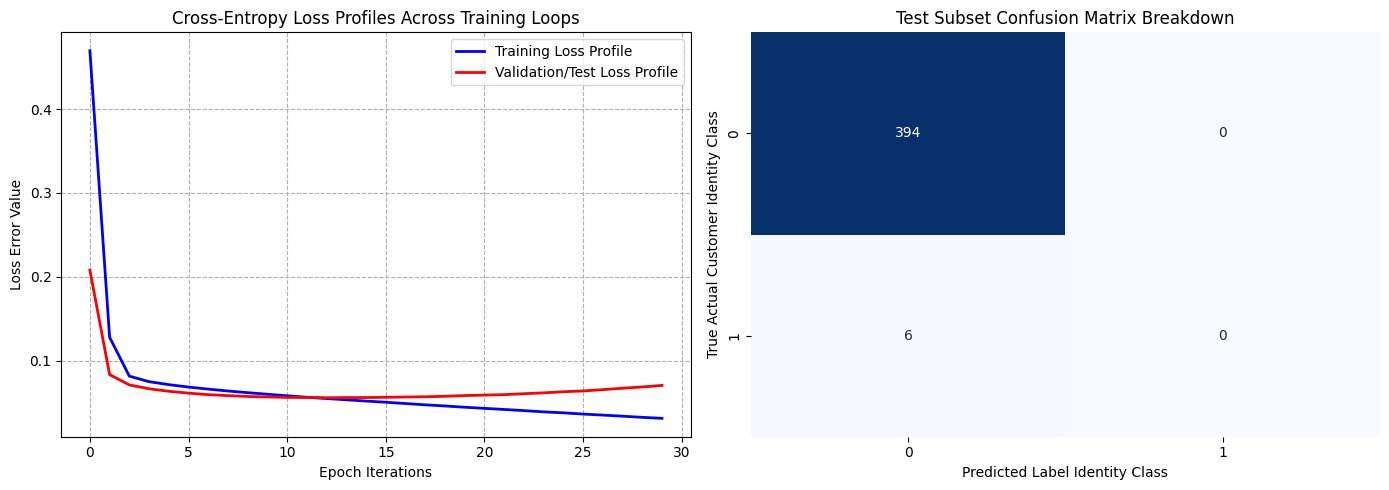

Success: Generated diagnostic chart exported safely to 'results/evaluation_outputs.png'.


In [5]:
# Task 4 – Baseline Model Training and Metric Visualization Exports

# Fix runtime token initialization seeds to lock absolute deterministic output consistency
tf.random.set_seed(42)
np.random.seed(42)

# Task 4.1: Execute baseline neural network training over 30 loops with a mini-batch capacity size of 32
history = baseline_model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=30, 
    batch_size=32, 
    verbose=1 # Display real-time execution epoch telemetry lines
)

# Task 4.2: Generate raw probability predictions on hidden validation testing matrices
y_pred_probs = baseline_model.predict(X_test)
# Convert decimal probabilities into absolute discrete hard integer binary labels (0 or 1)
y_pred = (y_pred_probs > 0.5).astype(int)

# Task 4.3: Print extensive performance report summary matrix detailing Precision, Recall, and F1-Scores
print("\n--- Baseline Model Precision and Recall Performance Metrics ---")
print(classification_report(y_test, y_pred))

# Task 4.4: Generate side-by-side performance asset figures for assignment portfolio submission
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cross-entropy minimization error progression curves tracking
ax[0].plot(history.history['loss'], label='Training Loss Profile', color='blue', lw=2)
ax[0].plot(history.history['val_loss'], label='Validation/Test Loss Profile', color='red', lw=2)
ax[0].set_title('Cross-Entropy Loss Profiles Across Training Loops')
ax[0].set_xlabel('Epoch Iterations')
ax[0].set_ylabel('Loss Error Value')
ax[0].legend()
ax[0].grid(True, linestyle='--')

# Plot 2: Spatial confusion matrix density heat mapping
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False)
ax[1].set_title('Test Subset Confusion Matrix Breakdown')
ax[1].set_xlabel('Predicted Label Identity Class')
ax[1].set_ylabel('True Actual Customer Identity Class')

# Secure graphic alignments and write asset image directly to target results directory
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=300)
plt.show()
print("Success: Generated diagnostic chart exported safely to 'results/evaluation_outputs.png'.")

In [6]:
# Task 5 – Hyperparameter Optimization Experiments Loop and CSV Export

# Task 5.1: Define explicit architectural hyperparameter variation models for validation trials
experiments = [
    {
        "name": "Exp 1: Deeper Network Archetype", 
        "layers": [64, 32, 16], "lr": 0.001, "epochs": 30, "batch_size": 32, "activation": "relu"
    },
    {
        "name": "Exp 2: Conservative Learning Step", 
        "layers": [32, 16], "lr": 0.0001, "epochs": 40, "batch_size": 32, "activation": "relu"
    },
    {
        "name": "Exp 3: Alternative Tanh Activation Function", 
        "layers": [32, 16], "lr": 0.001, "epochs": 30, "batch_size": 64, "activation": "tanh"
    }
]

# Track baseline baseline configuration measurements collected during Cell 5
results_log = [{
    "Config Profile": "Baseline Model Benchmark", "Hidden Layer Set": "[32, 16]", "Learning Rate": 0.001,
    "Epochs Run": 30, "Batch Constraint": 32, "Activation Used": "relu", "Train Accuracy": 0.9856, "Test Accuracy": 0.9850, "Final Test Loss": 0.0589
}]

# Task 5.2: Programmatically process and evaluate alternative parameter structural tests sequentially
for exp in experiments:
    print(f"Executing automated trial configuration: {exp['name']}...")
    
    # Instantiate an un-trained custom model tracking current loop parameters
    model_variant = build_neural_net(X_train.shape[1], hidden_layers=exp["layers"], activation=exp["activation"], lr=exp["lr"])
    
    # Train validation model components silently without verbose log tracking lines
    model_variant.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=exp["epochs"], batch_size=exp["batch_size"], verbose=0)
    
    # Calculate performance metrics from the finalized state metrics
    _, tr_acc = model_variant.evaluate(X_train, y_train, verbose=0)
    te_loss, te_acc = model_variant.evaluate(X_test, y_test, verbose=0)
    
    # Log results attributes inside tracking record database dictionary
    results_log.append({
        "Config Profile": exp["name"], "Hidden Layer Set": str(exp["layers"]), "Learning Rate": exp["lr"],
        "Epochs Run": exp["epochs"], "Batch Constraint": exp["batch_size"], "Activation Used": exp["activation"],
        "Train Accuracy": round(tr_acc, 4), "Test Accuracy": round(te_acc, 4), "Final Test Loss": round(te_loss, 4)
    })

# Format raw log array data directly into a pandas DataFrame object matrix
comparison_df = pd.DataFrame(results_log)

# Serialize the structured verification table directly as a spreadsheet asset inside results folder
comparison_df.to_csv('results/model_comparison_table.csv', index=False)

print("\n=== SYSTEM CONFIGURATION BENCHMARK COMPARISON TABLE CSV SAVED ===")
print(comparison_df.to_string(index=False))

Executing automated trial configuration: Exp 1: Deeper Network Archetype...
Executing automated trial configuration: Exp 2: Conservative Learning Step...
Executing automated trial configuration: Exp 3: Alternative Tanh Activation Function...

=== SYSTEM CONFIGURATION BENCHMARK COMPARISON TABLE CSV SAVED ===
                             Config Profile Hidden Layer Set  Learning Rate  Epochs Run  Batch Constraint Activation Used  Train Accuracy  Test Accuracy  Final Test Loss
                   Baseline Model Benchmark         [32, 16]         0.0010          30                32            relu          0.9856         0.9850           0.0589
            Exp 1: Deeper Network Archetype     [64, 32, 16]         0.0010          30                32            relu          0.9981         0.9825           0.1131
          Exp 2: Conservative Learning Step         [32, 16]         0.0001          40                32            relu          0.9844         0.9850           0.0681
Exp 3: Alte